### 1. Convert TensorFlow SavedModel to TFLite Format and Generate Labels File for Android Deployment


In [26]:
import tensorflow as tf
import os
import logging
import json


# In the first stage, I convert my SavedModel to TFLite

# I store the current log level
prev_log_level = tf.get_logger().level

# Suppress logs for this cell ( I try to show only errors)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel(logging.ERROR)


saved_model_dir = "saved_model_tf"  # Path to your TensorFlow SavedModel
output_dir = "../dog_prepare_tflite"  # Create inside Dissertation
os.makedirs(output_dir, exist_ok=True)
tflite_path = os.path.join(output_dir, "mobilenet_dogbreed.tflite")

# Initialize TFLite Converter from my SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)

# Enable optimization for smaller size (quantization)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

#  I use only built-in ops for Android compatibility
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

# Convert the model to TFLite format
tflite_model = converter.convert()

# I'm saving the converted TFLite model
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"TFLite model successfully saved at: {tflite_path}")


# In the second stage, I create labels.txt for Android App


# Path to class indices JSON file
json_path = "class_indices_mobilenet.json"

# Load class names from JSON
with open(json_path, "r") as f:
    class_indices = json.load(f)

class_names = list(class_indices.keys())  # Extract class names

# Path to save labels.txt in the output directory
labels_txt_path = os.path.join(output_dir, "labels.txt")

# Write labels to the file
with open(labels_txt_path, "w") as f:
    for label in class_names:
        f.write(label + "\n")

print(f"labels.txt successfully created at: {labels_txt_path}")

# Restore the original log level
tf.get_logger().setLevel(prev_log_level)

TFLite model successfully saved at: ../dog_prepare_tflite/mobilenet_dogbreed.tflite
labels.txt successfully created at: ../dog_prepare_tflite/labels.txt


#### Description of Convert TensorFlow SavedModel to TFLite Format and Generate Labels File for Android Deployment
In this part, I will carry out two important tasks to finalize my trained model for deployment on mobile devices.
1. Convert TensorFlow SavedModel to TFLite format:
- I create a TFLite converter from my existing TensorFlow SavedModel.
- I enable optimization reducing the size of the files (quantization).
- I set the converter to only use operations which are supported by TensorFlow Lite for Android.
- Finally, I convert the model and export it as a .tflite file for use in the app.
  
2. Create labels.txt for the Android app
- I load the class names from the JSON file (class_indices_mobilenet.json) I previously saved.
- I capture all class labels and write them one per line in a file called labels.txt.
- This allows the Android app to get the model prediction and attach the labels of the breed names.

By completing these steps I have created an optimized model for mobile devices as well as all the resources (model file and labels) necessary for the Android application.

### 2. Load and Test TFLite Model with a Single Image

Predicted Breed: kelpie


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


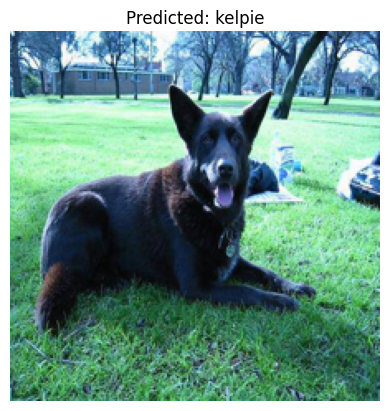

In [28]:
 

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
import shutil

# I define paths
prepare_dir = os.path.abspath("../dog_prepare_tflite")  # Folder where TFLite and labels are stored
tflite_model_path = os.path.join(prepare_dir, "mobilenet_dogbreed.tflite")
labels_path = os.path.join(prepare_dir, "labels.txt")

# Load labels from  my labels.txt
with open(labels_path, "r") as f:
    labels = [line.strip() for line in f.readlines()]

#  Also, load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

#  I wrote these lines of code for selecting a test image from the dataset
source_image_path = "dataset_dog_breed_identification/main_dataset/0a4116a80e753f7b0adf4149f551a3a7.jpg"
test_image_path = os.path.join(prepare_dir, os.path.basename(source_image_path))
shutil.copy(source_image_path, test_image_path)  # Copy image for reference (optional)

# Load and preprocess the image that I put in my foldre for testing
image = Image.open(test_image_path).resize((224, 224))  # Resize to MobileNetV2 input size
input_image = np.array(image) / 255.0  # Normalize to range [0, 1]
input_image = np.expand_dims(input_image.astype(np.float32), axis=0)  # Add batch dimension

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_image)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

#  Finally, I try to get prediction
predicted_index = np.argmax(output_data)
predicted_label = labels[predicted_index]

# Showing my result
print(f"Predicted Breed: {predicted_label}")
plt.imshow(image)
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()

#### Description of Load and Test TFLite Model with a Single Image

In this phase, I am testing my converted TFLite model. To do so, I will run inference on a single image from my dataset:

1. Define paths:

- I define the directory for my converted TFLite model (mobilenet_dogbreed.tflite) and the labels file (labels.txt).
    
2. Load class labels:

- I read all of the breed names from the labels.txt file into a list so I can map the prediction index to a breed   name.


3. Load the TFLite model:

- I create a TFLite interpreter using the model file path, and allocate tensors for running inference.
    
4. Get model inputs and outputs:

- I retrieve the input and output tensor details from the interpreter so I can correctly format my data for inference.

5. Select and prepare test image:


- I copy an example from my dataset to use for reference.
- I open the image, resize it to 224×224 (the input size of MobileNetV2), normalize the pixel ranges to [0, 1], and expand dimensions so that I have the image shape consistent with the input shape for the model with the addition of a batch axis.

6. Run inference:
   
- I set the preprocessed image as input to the model and call the interpreter to generate predictions for the image.

8. Get prediction and display result:
   
- I use the index of the prediction with the highest value, and use this as the index to look up the breed name, and then I display the image with predicted label using Matplotlib.

**By completing this step, I have confirmed that my TFLite model works as expected and can classify a single test image prior to deployment in the mobile application.**
    


### Check Versian

In [3]:
import sys
import tensorflow as tf
import numpy as np

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

Python version: 3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]
TensorFlow version: 2.14.0
NumPy version: 1.26.4
